# Project data exploration - looking at relplot and scatter plots
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

*Group name:*  CrimeFighters101

*Created by:* Emily Leson (016816826), Shannon Lo (017287452), Ynha Nguyen (SJSU ID), Tyler Awender (015801890)

*Last updated:* Sunday, March 22 @ 6:00 PM

<br>

**Dataset Description:**

*Context*

As students at SJSU, campus safety is a topic that is relevant and personal to all of us. This project was motivated by a desire to better understand crime trends across the CSU system as a whole. The CSU system serves over 460,000 students across 22 campuses statewide, providing us with lots of data for analyzing patterns in campus crime and safety.

*Data Source*

We sourced the data for this project from the U.S. Department of Education's Campus Safety and Security website- they provide a Data Analysis Cutting Tool which we used to compile crime and safety statistics that institutions are legally required to report.

*Data Content*

The dataset includes annual campus crime and safety statistics. Specifically, criminal offense counts (such as burglary, assault, and rape), hate crimes, VAWA offenses, arrests and disciplinary referrals for drug, liquor, and weapon violations, and fire safety statistics. The data is broken down by campus location type (on-campus, residential, public property, non-campus) and spans from 2001to 2023. For relevance, we are going to focus on the last decade or so, specifically 2015-2023. We also filtered the dataset to all 22 CSU campuses, and were able to download institution-level records in CSV format.


In [34]:
import pandas as pd

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

In [35]:
from google.colab import drive
drive.mount('/content/drive')

## data file path: /content/drive/MyDrive/Colab Notebooks/Data

#path = '/content/drive/MyDrive/Colab Notebooks/Data/OPE CSS Custom Data 2026-03-05 212733/'
path = '/content/drive/MyDrive/cs133/OPE CSS Custom Data 2026-03-05 212733/'

#arrests_local_state_police = pd.read_csv(path+"Arrests_Local_State_Police.csv")
arrests_noncampus = pd.read_csv(path+"Arrests_Noncampus.csv")
arrests_on_campus = pd.read_csv(path+"Arrests_On_campus.csv")
arrests_on_student_housing = pd.read_csv(path+"Arrests_On_campus_Student_Housing_Facilities.csv")
arrests_public_property = pd.read_csv(path+"Arrests_Public_Property.csv")

criminal_offenses_noncampus = pd.read_csv(path+"Criminal_Offenses_Noncampus.csv")
criminal_offenses_on_campus = pd.read_csv(path+"Criminal_Offenses_On_campus.csv")
criminal_offenses_on_student_housing = pd.read_csv(path+"Criminal_Offenses_On_campus_Student_Housing_Facilities.csv")
criminal_offenses_public_property = pd.read_csv(path+"Criminal_Offenses_Public_Property.csv")

detailed_fire_data = pd.read_csv(path+"Detailed_Fire_Data.csv")

disciplinary_actions_noncampus = pd.read_csv(path+"Disciplinary_Actions_Noncampus.csv")
disciplinary_actions_on_campus = pd.read_csv(path+"Disciplinary_Actions_On_campus.csv")
disciplinary_actions_public_property = pd.read_csv(path+"Disciplinary_Actions_Public_Property.csv")
disciplinary_actions_student_housing = pd.read_csv(path+"Disciplinary_Actions_Student_Housing_Facilities.csv")

hate_crimes_noncampus = pd.read_csv(path+"Hate_Crimes_Noncampus.csv")
hate_crimes_on_campus = pd.read_csv(path+"Hate_Crimes_On_campus.csv")
hate_crimes_student_housing = pd.read_csv(path+"Hate_Crimes_On_campus_Student_Housing_Facilities.csv")
hate_crimes_public_property = pd.read_csv(path+"Hate_Crimes_Public_Property.csv")

total_fires = pd.read_csv(path+"Total_Fires_On_campus_Student_Housing_Facilities.csv")

unfounded_crimes = pd.read_csv(path+"Unfounded_Crimes.csv")

vawa_offenses_noncampus = pd.read_csv(path+"VAWA_Offenses_Noncampus.csv")
vawa_offenses_on_campus = pd.read_csv(path+"VAWA_Offenses_On_campus.csv")
vawa_offenses_student_housing = pd.read_csv(path+"VAWA_Offenses_On_campus_Student_Housing_Facilities.csv")
vawa_offenses_public_property = pd.read_csv(path+"VAWA_Offenses_Public_Property.csv")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# Needed to use .strip() to clean column names to not include \t and other whiteapsce additions

for name, df in dataframes.items():
    df.columns = df.columns.str.strip().str.replace(r'[\t\n]+', ' ', regex=True)
    dataframes[name] = df

# Reassign back to original variables
arrests_noncampus = dataframes['arrests_noncampus']
arrests_on_campus = dataframes['arrests_on_campus']
arrests_on_student_housing = dataframes['arrests_on_student_housing']
arrests_public_property = dataframes['arrests_public_property']
criminal_offenses_noncampus = dataframes['criminal_offenses_noncampus']
criminal_offenses_on_campus = dataframes['criminal_offenses_on_campus']
criminal_offenses_on_student_housing = dataframes['criminal_offenses_on_student_housing']
criminal_offenses_public_property = dataframes['criminal_offenses_public_property']
detailed_fire_data = dataframes['detailed_fire_data']
disciplinary_actions_noncampus = dataframes['disciplinary_actions_noncampus']
disciplinary_actions_on_campus = dataframes['disciplinary_actions_on_campus']
disciplinary_actions_public_property = dataframes['disciplinary_actions_public_property']
disciplinary_actions_student_housing = dataframes['disciplinary_actions_student_housing']
hate_crimes_noncampus = dataframes['hate_crimes_noncampus']
hate_crimes_on_campus = dataframes['hate_crimes_on_campus']
hate_crimes_student_housing = dataframes['hate_crimes_student_housing']
hate_crimes_public_property = dataframes['hate_crimes_public_property']
total_fires = dataframes['total_fires']
unfounded_crimes = dataframes['unfounded_crimes']
vawa_offenses_noncampus = dataframes['vawa_offenses_noncampus']
vawa_offenses_on_campus = dataframes['vawa_offenses_on_campus']
vawa_offenses_student_housing = dataframes['vawa_offenses_student_housing']
vawa_offenses_public_property = dataframes['vawa_offenses_public_property']

### Q1: Show the number of missing data in each column of the dataframe (Shannon)

In [38]:
# Create dictionary of all dataframes

dataframes = {
    'arrests_noncampus': arrests_noncampus,
    'arrests_on_campus': arrests_on_campus,
    'arrests_on_student_housing': arrests_on_student_housing,
    'arrests_public_property': arrests_public_property,
    'criminal_offenses_noncampus': criminal_offenses_noncampus,
    'criminal_offenses_on_campus': criminal_offenses_on_campus,
    'criminal_offenses_on_student_housing': criminal_offenses_on_student_housing,
    'criminal_offenses_public_property': criminal_offenses_public_property,
    'detailed_fire_data': detailed_fire_data,
    'disciplinary_actions_noncampus': disciplinary_actions_noncampus,
    'disciplinary_actions_on_campus': disciplinary_actions_on_campus,
    'disciplinary_actions_public_property': disciplinary_actions_public_property,
    'disciplinary_actions_student_housing': disciplinary_actions_student_housing,
    'hate_crimes_noncampus': hate_crimes_noncampus,
    'hate_crimes_on_campus': hate_crimes_on_campus,
    'hate_crimes_student_housing': hate_crimes_student_housing,
    'hate_crimes_public_property': hate_crimes_public_property,
    'total_fires': total_fires,
    'unfounded_crimes': unfounded_crimes,
    'vawa_offenses_noncampus': vawa_offenses_noncampus,
    'vawa_offenses_on_campus': vawa_offenses_on_campus,
    'vawa_offenses_student_housing': vawa_offenses_student_housing,
    'vawa_offenses_public_property': vawa_offenses_public_property,
}

# Display missing value counts for each dataframe
for name, df in dataframes.items():
    missing = df.isnull().sum()
    missing_only = missing[missing > 0]  # Filter to only columns with missing values

    print(f"DataFrame: {name}  |  Shape: {df.shape}")
    print(" ")

    if missing_only.empty:
        print("No missing values")
    else:
        print(f"Total missing cells: {missing_only.sum()}")
        print(missing_only.to_string())

DataFrame: arrests_noncampus  |  Shape: (212, 10)
 
No missing values
DataFrame: arrests_on_campus  |  Shape: (395, 10)
 
No missing values
DataFrame: arrests_on_student_housing  |  Shape: (229, 10)
 
No missing values
DataFrame: arrests_public_property  |  Shape: (395, 10)
 
No missing values
DataFrame: criminal_offenses_noncampus  |  Shape: (212, 20)
 
Total missing cells: 424
Sex offenses - Forcible        212
Sex offenses - Non-forcible    212
DataFrame: criminal_offenses_on_campus  |  Shape: (395, 20)
 
Total missing cells: 790
Sex offenses - Forcible        395
Sex offenses - Non-forcible    395
DataFrame: criminal_offenses_on_student_housing  |  Shape: (229, 20)
 
Total missing cells: 458
Sex offenses - Forcible        229
Sex offenses - Non-forcible    229
DataFrame: criminal_offenses_public_property  |  Shape: (395, 20)
 
Total missing cells: 790
Sex offenses - Forcible        395
Sex offenses - Non-forcible    395
DataFrame: detailed_fire_data  |  Shape: (273, 14)
 
Total mis

### Q2: Show the data type for each column of the dataframe (Shannon)

In [39]:
# Display data types for each dataframe

for name, df in dataframes.items():
    print(f"\n")
    print(f"DataFrame: {name}  |  Shape: {df.shape}")
    print(f"\n")
    print(df.dtypes.to_string())



DataFrame: arrests_noncampus  |  Shape: (212, 10)


Survey year                    int64
Unitid                         int64
Institution name              object
OPEID                          int64
Campus ID                      int64
Campus Name                   object
Institution Size               int64
Illegal weapons possession     int64
Drug law violations            int64
Liquor law violations          int64


DataFrame: arrests_on_campus  |  Shape: (395, 10)


Survey year                    int64
Unitid                         int64
Institution name              object
OPEID                          int64
Campus ID                      int64
Campus Name                   object
Institution Size               int64
Illegal weapons possession     int64
Drug law violations            int64
Liquor law violations          int64


DataFrame: arrests_on_student_housing  |  Shape: (229, 10)


Survey year                    int64
Unitid                         int64
Institution nam

### Q3: Create a pair plot to show pairwise relationship in this dataset. (Ynha)
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

In [40]:
print(criminal_offenses_on_campus.columns.tolist())

['Survey year', 'Unitid', 'Institution name', 'OPEID', 'Campus ID', 'Campus Name', 'Institution Size', 'Murder/Non-negligent manslaughter', 'Negligent manslaughter', 'Sex offenses - Forcible', 'Rape', 'Fondling', 'Sex offenses - Non-forcible', 'Incest', 'Statutory rape', 'Robbery', 'Aggravated assault', 'Burglary', 'Motor vehicle theft', 'Arson']


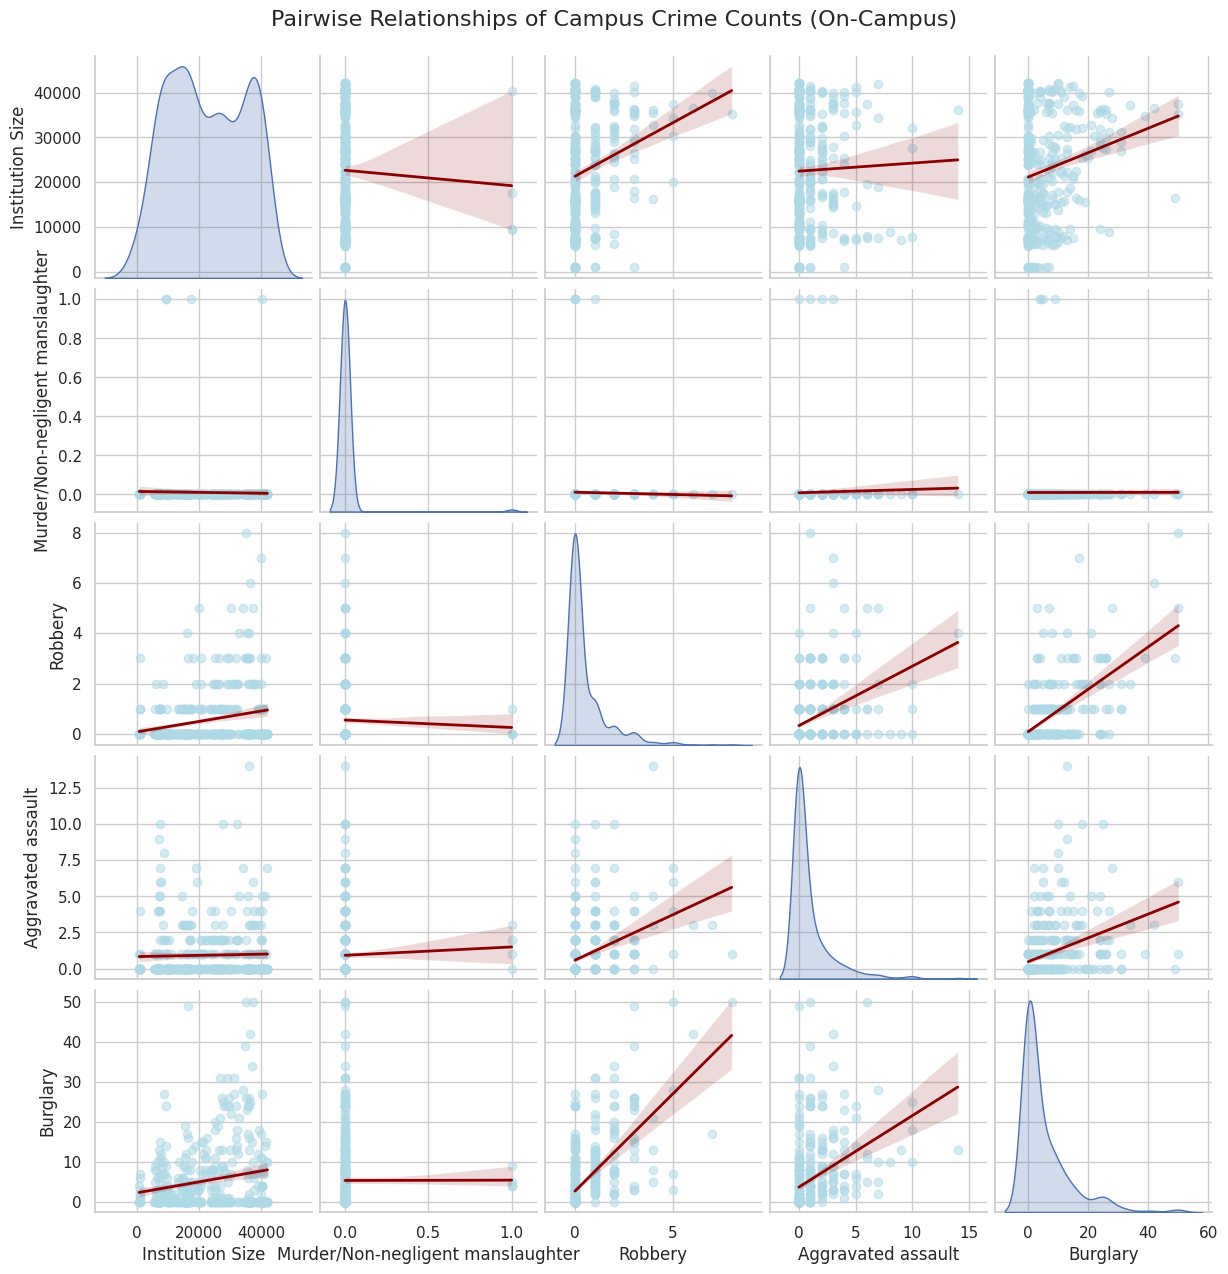

In [41]:
# Your code here . . .
import seaborn as sns
import matplotlib.pyplot as plt

crimes = criminal_offenses_on_campus[[
    "Institution Size",
    "Murder/Non-negligent manslaughter",
    "Robbery",
    "Aggravated assault",
    "Burglary"
]]

sns.set(style="whitegrid")

pair_plot = sns.pairplot(
    crimes,
    kind="reg",
    diag_kind="kde",
    plot_kws={
        "scatter_kws": {
            "color": "lightblue",
            "alpha": 0.5
        },
        "line_kws": {
            "color": "darkred",
            "linewidth": 2
        }
    }
)

pair_plot.fig.suptitle(
    "Pairwise Relationships of Campus Crime Counts (On-Campus)",
    fontsize=16,
    y=1.02
)

plt.show()


### Q4: Plot a regression line and confidence interval (Ynha)
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

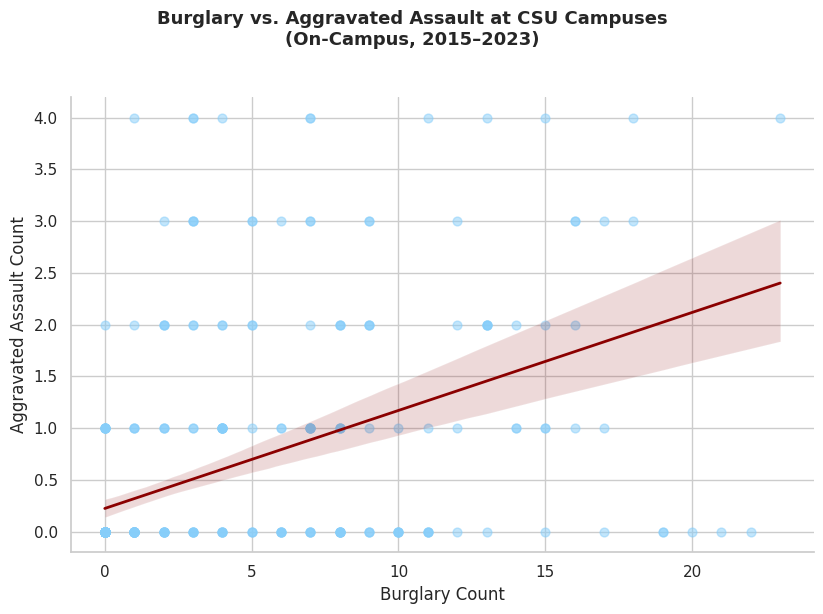

In [ ]:
import pandas as pd

df_q4 = criminal_offenses_on_campus[['Survey year', 'Institution name', 'Burglary', 'Aggravated assault']].copy()

df_q4 = df_q4[df_q4['Survey year'].between(2015, 2023)]

df_q4['Burglary'] = pd.to_numeric(df_q4['Burglary'], errors='coerce')
df_q4['Aggravated assault'] = pd.to_numeric(df_q4['Aggravated assault'], errors='coerce')
df_q4 = df_q4.dropna()

df_q4 = df_q4[
    (df_q4['Burglary'] < df_q4['Burglary'].quantile(0.95)) &
    (df_q4['Aggravated assault'] < df_q4['Aggravated assault'].quantile(0.95))
]

reg_line = sns.lmplot(
    data=df_q4,
    x='Burglary',
    y='Aggravated assault',
    height=6,
    aspect=1.4,
    scatter_kws={'alpha': 0.5, 'color': 'lightskyblue', 's': 40},
    line_kws={'color': 'darkred', 'linewidth': 2},
    ci=95
)

reg_line.figure.suptitle(
    'Burglary vs. Aggravated Assault at CSU Campuses\n(On-Campus, 2015–2023)',
    y=1.02, fontsize=13, fontweight='bold'
)
reg_line.set_axis_labels('Burglary Count', 'Aggravated Assault Count')

plt.tight_layout()
plt.show()

### Q5. Create a relplot that shows multiple features in a single plot. (Tyler)
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

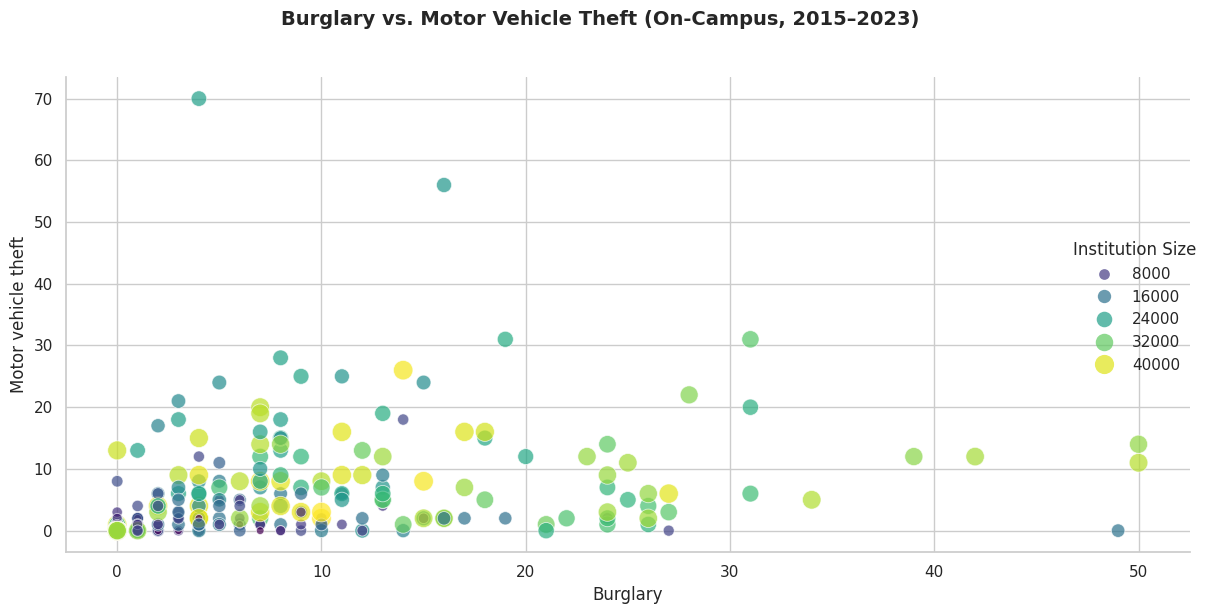

In [58]:
g = sns.relplot(
    data=df_q5,
    x="Burglary",
    y="Motor vehicle theft",
    hue="Institution Size",        # color by institution size
    size="Institution Size",       # keep size mapping too (optional)
    kind="scatter",
    height=6,
    aspect=1.8,
    palette="viridis",             # good continuous colormap
    alpha=0.7,
    sizes=(30, 200)                # min/max marker size
)

g.fig.suptitle(
    "Burglary vs. Motor Vehicle Theft (On-Campus, 2015–2023)",
    y=1.02,
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

/tmp/ipykernel_2075/2243186851.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_q6_filtered['Burglary'] = pd.to_numeric(df_q6_filtered['Burglary'], errors='coerce')
/tmp/ipykernel_2075/2243186851.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_q6_filtered['Motor vehicle theft'] = pd.to_numeric(df_q6_filtered['Motor vehicle theft'], errors='coerce')
/tmp/ipykernel_2075/2243186851.py:22: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.relplot(


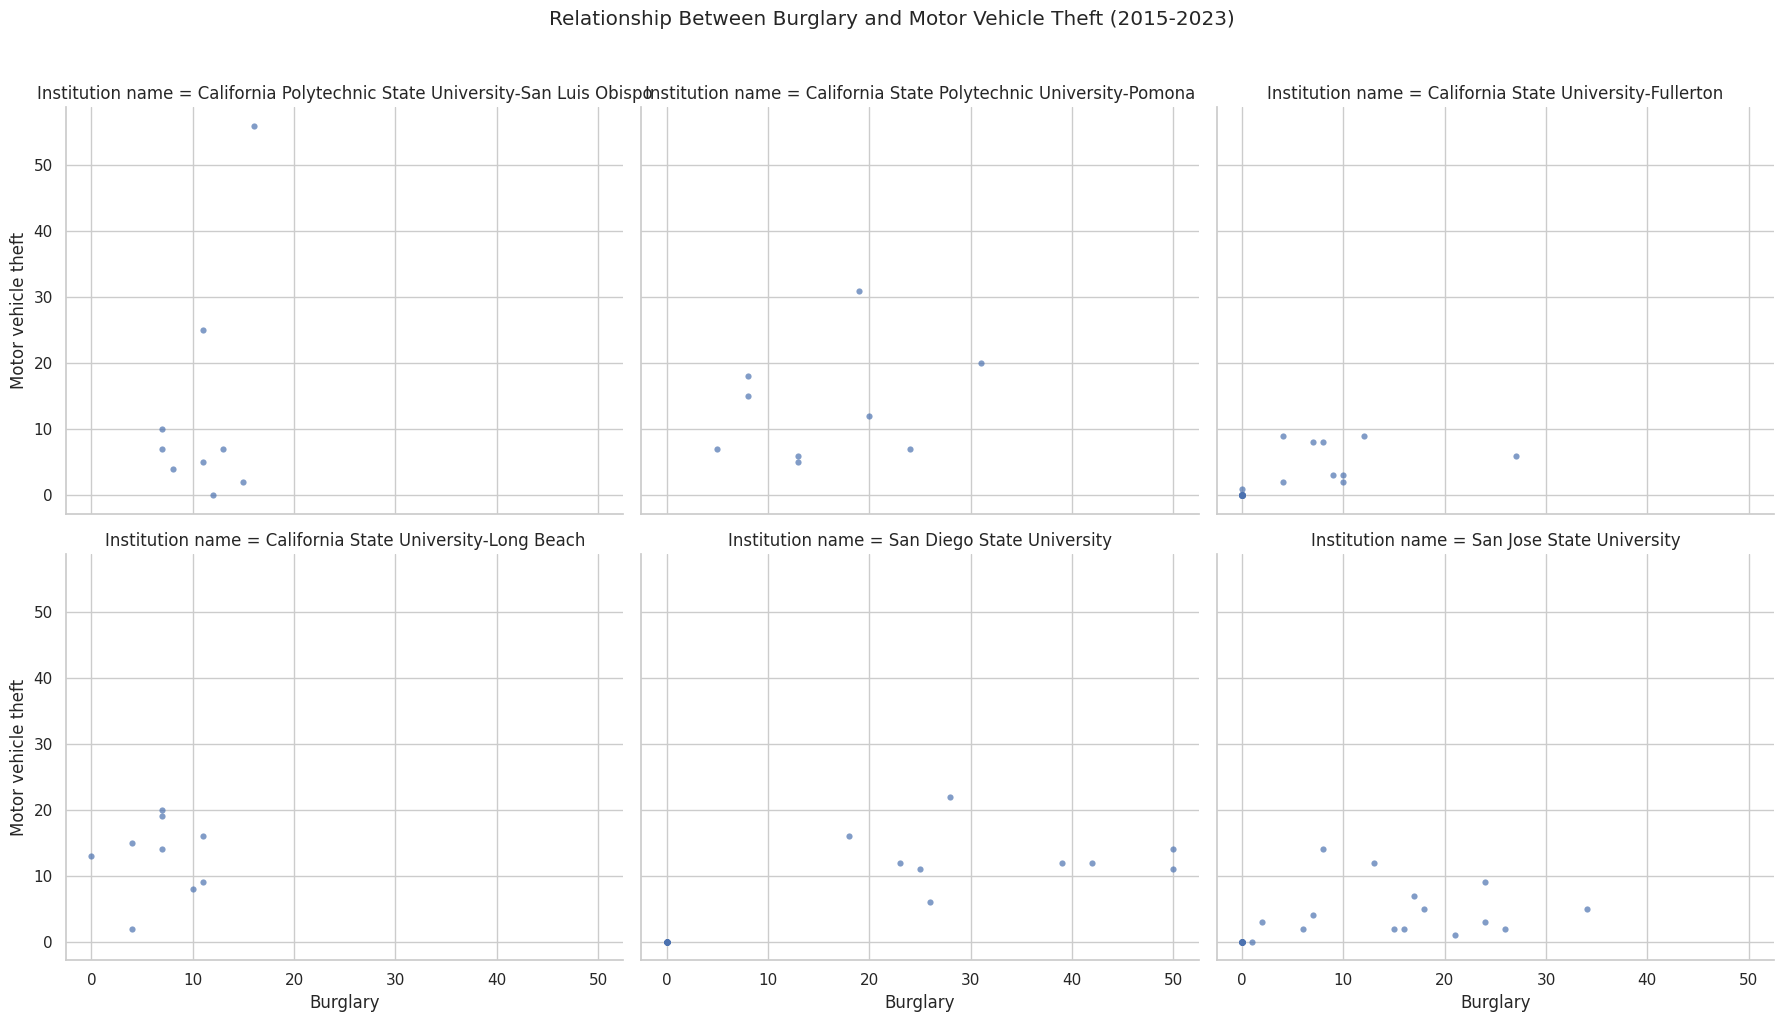

In [43]:
# Filter data for the requested years (2015-2023)
df_q6 = criminal_offenses_on_campus[criminal_offenses_on_campus['Survey year'].between(2015, 2023)].copy()

# Select a subset of institutions for clarity in small multiples
selected_institutions = [
    'California Polytechnic State University-San Luis Obispo',
    'California State Polytechnic University-Pomona',
    'California State University-Long Beach',
    'San Jose State University',
    'San Diego State University',
    'California State University-Fullerton'
]

df_q6_filtered = df_q6[df_q6['Institution name'].isin(selected_institutions)]

# Convert relevant columns to numeric, coercing errors to NaN and dropping missing values
df_q6_filtered['Burglary'] = pd.to_numeric(df_q6_filtered['Burglary'], errors='coerce')
df_q6_filtered['Motor vehicle theft'] = pd.to_numeric(df_q6_filtered['Motor vehicle theft'], errors='coerce')
df_q6_filtered = df_q6_filtered.dropna(subset=['Burglary', 'Motor vehicle theft'])

# Create the relplot with small multiples
g = sns.relplot(
    data=df_q6_filtered,
    x='Burglary',
    y='Motor vehicle theft',
    col='Institution name', # Feature for small multiples
    col_wrap=3, # 3 plots per row
    kind='scatter',
    height=5, # Height of each facet
    aspect=1.2,
    s=20, # Size of data points
    palette='viridis',
    linewidth=0, # Remove line around points for better visibility with small size
    alpha=0.7
)

# Add a meaningful title to the plot
g.fig.suptitle('Relationship Between Burglary and Motor Vehicle Theft (2015-2023)', y=1.02)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()